# Week 2: Read Administrative Boundary Data

## Goals
- Read Japanese administrative boundary data
- Inspect columns and CRS
- Filter the Tokyo metropolitan study area
- Prepare for mapping and later spatial joins

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

print("geopandas:", gpd.__version__)
print("pandas:", pd.__version__)

geopandas: 1.1.3
pandas: 3.0.1


In [2]:
import sys
from pathlib import Path

_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from tokyo_foreigners.paths import PROJECT_ROOT, DATA_RAW_DIR
from tokyo_foreigners.boundaries import (
    load_boundaries,
    project_gdf,
    filter_tokyo_metro_by_prefecture,
    clip_mainland_bbox,
    select_case_areas_by_keywords,
)

project_root = PROJECT_ROOT
data_raw = DATA_RAW_DIR

print("Project root (canonical):", project_root)
print("Raw data dir (canonical):", data_raw)

Project root (canonical): E:\rsch\laborJapan
Raw data dir (canonical): E:\rsch\laborJapan\data_raw


In [3]:
boundary_path = data_raw / "N03-20250101_GML" / "N03-20250101.shp"
print("Boundary path:", boundary_path)
print("Exists:", boundary_path.exists())

gdf = load_boundaries(boundary_path)

print("Rows, Columns:", gdf.shape)
gdf.head()

Boundary path: E:\rsch\laborJapan\data_raw\N03-20250101_GML\N03-20250101.shp
Exists: True
Rows, Columns: (124094, 7)


,N03_001,N03_002,N03_003,N03_004,N03_005,N03_007,geometry
0,北海道,石狩振興局,NaN,札幌市,中央区,01101,"POLYGON ((141.34233 43.06682, 141.34285 43.066..."
1,北海道,石狩振興局,NaN,札幌市,北区,01102,"POLYGON ((141.40839 43.18395, 141.40833 43.183..."
2,北海道,石狩振興局,NaN,札幌市,東区,01103,"POLYGON ((141.44707 43.15616, 141.44694 43.155..."
3,北海道,石狩振興局,NaN,札幌市,白石区,01104,"POLYGON ((141.46244 43.1001, 141.46265 43.1000..."
4,北海道,石狩振興局,NaN,札幌市,豊平区,01105,"POLYGON ((141.38463 43.0467, 141.38479 43.0466..."


In [4]:
print(gdf.columns.tolist())
print("CRS:", gdf.crs)

['N03_001', 'N03_002', 'N03_003', 'N03_004', 'N03_005', 'N03_007', 'geometry']
CRS: EPSG:6668


In [5]:
gdf.head(10).T

,0,1,2,3,4,5,6,7,8,9
N03_001,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道,北海道
N03_002,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局,石狩振興局
N03_003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
N03_004,札幌市,札幌市,札幌市,札幌市,札幌市,札幌市,札幌市,札幌市,札幌市,札幌市
N03_005,中央区,北区,東区,白石区,豊平区,南区,西区,厚別区,手稲区,清田区
N03_007,01101,01102,01103,01104,01105,01106,01107,01108,01109,01110
geometry,"POLYGON ((141.342326939337 43.06681583788077, ...",POLYGON ((141.4083872238914 43.183947505373226...,POLYGON ((141.44707027207562 43.15616027887393...,POLYGON ((141.46244138825966 43.10009750479617...,POLYGON ((141.38463250258815 43.04669527876427...,POLYGON ((141.09829805421202 43.11763833344253...,"POLYGON ((141.3147830612894 43.09589417067963,...",POLYGON ((141.47370221778328 43.09417666701972...,POLYGON ((141.22510250317816 43.15999750528078...,POLYGON ((141.4541397275666 43.018174171301155...


In [6]:
gdf["N03_001"].dropna().unique()

<StringArray>
[ '北海道',  '青森県',  '岩手県',  '宮城県',  '秋田県',  '山形県',  '福島県',  '茨城県',  '栃木県',
  '群馬県',  '埼玉県',  '千葉県',  '東京都', '神奈川県',  '新潟県',  '富山県',  '石川県',  '福井県',
  '山梨県',  '長野県',  '岐阜県',  '静岡県',  '愛知県',  '三重県',  '滋賀県',  '京都府',  '大阪府',
  '兵庫県',  '奈良県', '和歌山県',  '鳥取県',  '島根県',  '岡山県',  '広島県',  '山口県',  '徳島県',
  '香川県',  '愛媛県',  '高知県',  '福岡県',  '佐賀県',  '長崎県',  '熊本県',  '大分県',  '宮崎県',
 '鹿児島県',  '沖縄県']
Length: 47, dtype: str

In [7]:
metro_pref = ["東京都", "埼玉県", "千葉県", "神奈川県"]

tokyo_metro = filter_tokyo_metro_by_prefecture(
    gdf,
    prefectures=metro_pref,
    prefecture_col="N03_001",
)

print("Tokyo metro shape:", tokyo_metro.shape)
tokyo_metro.head()

Tokyo metro shape: (10543, 7)


,N03_001,N03_002,N03_003,N03_004,N03_005,N03_007,geometry
32121,埼玉県,NaN,NaN,さいたま市,西区,11101,"POLYGON ((139.54776 35.9342, 139.54804 35.9341..."
32122,埼玉県,NaN,NaN,さいたま市,西区,11101,"POLYGON ((139.54776 35.9342, 139.5472 35.93414..."
32123,埼玉県,NaN,NaN,さいたま市,北区,11102,"POLYGON ((139.61753 35.96486, 139.61798 35.964..."
32124,埼玉県,NaN,NaN,さいたま市,大宮区,11103,"POLYGON ((139.63768 35.92278, 139.63804 35.922..."
32125,埼玉県,NaN,NaN,さいたま市,見沼区,11104,"POLYGON ((139.66718 35.96444, 139.66739 35.964..."


In [8]:
tokyo_mainland = clip_mainland_bbox(
    tokyo_metro,
    xmin=138.8,
    xmax=140.3,
    ymin=34.8,
    ymax=36.3,
)

print("Original:", tokyo_metro.shape)
print("Mainland:", tokyo_mainland.shape)

Original: (10543, 7)
Mainland: (3473, 7)


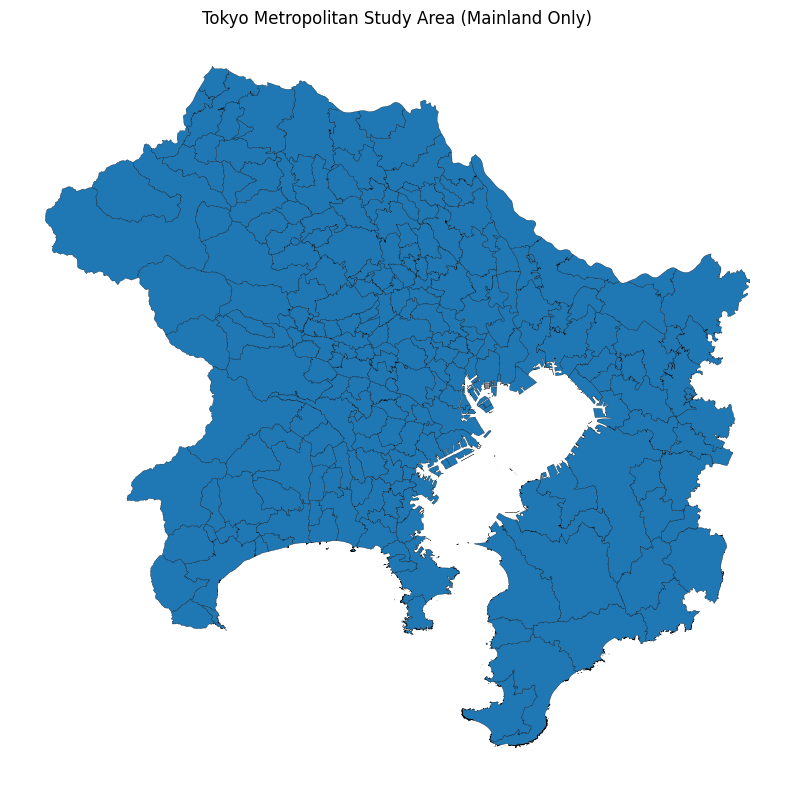

In [9]:
fig, ax = plt.subplots(figsize=(10, 10))
tokyo_mainland.plot(ax=ax, edgecolor="black", linewidth=0.2)
ax.set_title("Tokyo Metropolitan Study Area (Mainland Only)")
ax.set_axis_off()
plt.show()

In [10]:
tokyo_mainland_path = data_raw / "tokyo_metro_mainland.geojson"
tokyo_mainland.to_file(tokyo_mainland_path, driver="GeoJSON")

print(tokyo_mainland_path)
print(tokyo_mainland_path.exists())

E:\rsch\laborJapan\data_raw\tokyo_metro_mainland.geojson
True


In [11]:
tokyo_metro_path = data_raw / "tokyo_metro.geojson"
tokyo_metro.to_file(tokyo_metro_path, driver="GeoJSON")

In [12]:
tokyo_mainland[
    tokyo_mainland["N03_004"].astype(str).str.contains("川口", na=False) |
    tokyo_mainland["N03_005"].astype(str).str.contains("川口", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007"]].drop_duplicates()

,N03_001,N03_004,N03_005,N03_007
32134,埼玉県,川口市,NaN,11203


In [13]:
tokyo_mainland[
    tokyo_mainland["N03_004"].astype(str).str.contains("江戸川", na=False) |
    tokyo_mainland["N03_005"].astype(str).str.contains("江戸川", na=False)
][["N03_001", "N03_004", "N03_005", "N03_007"]].drop_duplicates()

,N03_001,N03_004,N03_005,N03_007
34750,東京都,江戸川区,NaN,13123


In [14]:
case_areas = select_case_areas_by_keywords(
    tokyo_mainland,
    keywords_pattern="川口|江戸川",
    col_primary="N03_004",
    col_secondary="N03_005",
)

case_areas[["N03_001", "N03_004", "N03_005", "N03_007"]].drop_duplicates()

,N03_001,N03_004,N03_005,N03_007
32134,埼玉県,川口市,NaN,11203
34750,東京都,江戸川区,NaN,13123


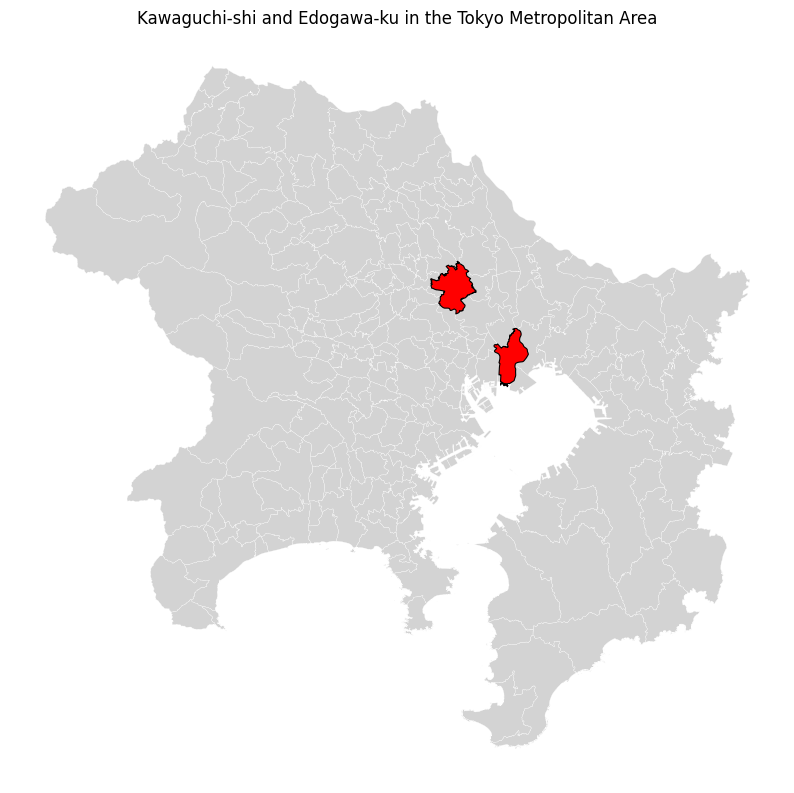

In [15]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_mainland.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
case_areas.plot(ax=ax, color="red", edgecolor="black", linewidth=0.8)

ax.set_title("Kawaguchi-shi and Edogawa-ku in the Tokyo Metropolitan Area")
ax.set_axis_off()
plt.show()

In [16]:
print(tokyo_mainland.crs)

EPSG:6668


In [17]:
tokyo_mainland_proj = project_gdf(tokyo_mainland, epsg=6677)
print("Projected CRS:", tokyo_mainland_proj.crs)

Projected CRS: EPSG:6677


In [18]:
case_areas_proj = project_gdf(case_areas, epsg=6677)
print("Case areas CRS:", case_areas_proj.crs)

Case areas CRS: EPSG:6677


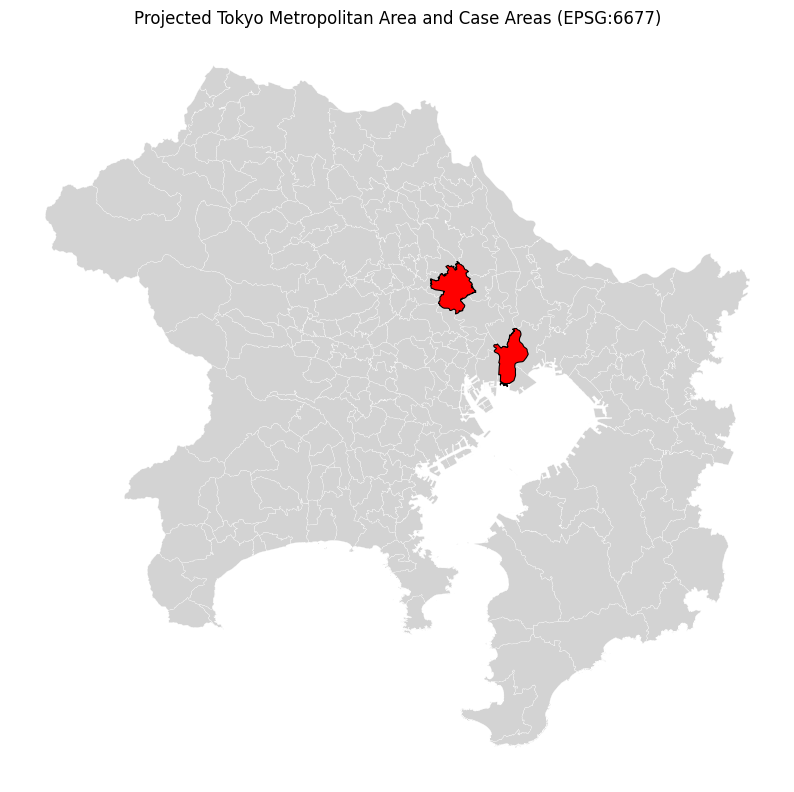

In [19]:
fig, ax = plt.subplots(figsize=(10, 10))

tokyo_mainland_proj.plot(ax=ax, color="lightgray", edgecolor="white", linewidth=0.2)
case_areas_proj.plot(ax=ax, color="red", edgecolor="black", linewidth=0.8)

ax.set_title("Projected Tokyo Metropolitan Area and Case Areas (EPSG:6677)")
ax.set_axis_off()
plt.show()

In [20]:
tokyo_mainland_proj_path = data_raw / "tokyo_metro_mainland_proj.geojson"
tokyo_mainland_proj.to_file(tokyo_mainland_proj_path, driver="GeoJSON")

print(tokyo_mainland_proj_path)
print(tokyo_mainland_proj_path.exists())

E:\rsch\laborJapan\data_raw\tokyo_metro_mainland_proj.geojson
True


In [21]:
case_areas_proj_path = data_raw / "case_areas_proj.geojson"
case_areas_proj.to_file(case_areas_proj_path, driver="GeoJSON")

print(case_areas_proj_path)
print(case_areas_proj_path.exists())

E:\rsch\laborJapan\data_raw\case_areas_proj.geojson
True
